# RHI Live Runtime v23 — H-Residence Analyzer

Δ **Purpose:** move beyond H-crossing and measure H-residence, H-runs, H-return, and null separation.

$$
\boxed{
\text{Crossing} \neq \text{Residence} \neq \text{Return}
}
$$

v22 proved that token-level fold logging works and that trajectories can cross the $H=\pi/9$ neighborhood. v23 asks the harder question:

$$
\boxed{
\text{Does the path live near }H\text{ more than a matched null would?}
}
$$

This notebook is **post-hoc**. It reads a v22 bundle and writes exactly two files:

1. `rhi_v23_<run_id>_bundle.json`
2. `rhi_v23_<run_id>_summary.csv`

No generation. No intervention. No repair. No threshold tuning toward $H$.


In [1]:

from __future__ import annotations

import os, json, math, uuid, random, statistics
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# Optional plotting: displayed inline only. No image files are written.
import matplotlib.pyplot as plt

ROOT = Path.cwd()
RUN_ID = "rhi_v23_" + uuid.uuid4().hex[:10]
OUT_DIR = ROOT / "rhi_v23_outputs"
OUT_DIR.mkdir(exist_ok=True)

# H is a readout/destination, not a steering target.
H_TARGET = math.pi / 9

# Residence thresholds.
EPSILONS = [0.001, 0.005, 0.01, 0.05]

# Null repetitions. Raise for a stronger run; lower for speed.
N_NULL = 1000

SEED = 23
random.seed(SEED)
np.random.seed(SEED)

# Optional manual input path. Leave None to auto-detect latest v22 bundle.
V22_BUNDLE_PATH = None

print("RHI v23 H-Residence Analyzer")
print("RUN_ID:", RUN_ID)
print("H_TARGET:", H_TARGET)
print("OUT_DIR:", OUT_DIR)


RHI v23 H-Residence Analyzer
RUN_ID: rhi_v23_1f5a545dca
H_TARGET: 0.3490658503988659
OUT_DIR: D:\Nexus\Nexus Mark 9\NoteBooks\rhi_v23_outputs



## 1. Load the v22 Bundle

The analyzer looks for the newest `rhi_v22_*_bundle.json` in the current folder and common output folders. You can override this by setting `V22_BUNDLE_PATH` in the first code cell.


In [2]:

def find_latest_v22_bundle(root: Path) -> Path:
    candidates = []
    patterns = [
        "rhi_v22_*_bundle.json",
        "**/rhi_v22_*_bundle.json",
    ]
    for pattern in patterns:
        candidates.extend(root.glob(pattern))
    candidates = sorted(set(candidates), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(
            "No rhi_v22_*_bundle.json found. Put the v22 bundle in this folder "
            "or set V22_BUNDLE_PATH manually."
        )
    return candidates[0]

bundle_path = Path(V22_BUNDLE_PATH) if V22_BUNDLE_PATH else find_latest_v22_bundle(ROOT)
print("Loading v22 bundle:", bundle_path)

with open(bundle_path, "r", encoding="utf-8") as f:
    v22 = json.load(f)

fold_logs = v22.get("fold_logs", [])
print("Loaded fold logs:", len(fold_logs))
print("Source run:", v22.get("run_id"))
print("Model:", v22.get("model"))


Loading v22 bundle: D:\Nexus\Nexus Mark 9\NoteBooks\rhi_v22_outputs\rhi_v22_1c37970b38_bundle.json
Loaded fold logs: 10
Source run: rhi_v22_1c37970b38
Model: Qwen/Qwen2.5-1.5B-Instruct



## 2. Metric Definitions

For each branch, v23 evaluates both channels already produced by v22:

$$
H_\ell^{(\text{entropy})} = S_\ell / S_{\max}
$$

$$
H_\ell^{(\text{confidence})} = C_\ell
$$

Then it computes:

### H-dwell

$$
D_H(\epsilon)=
\frac{
\#\{\ell: |H_\ell-\pi/9| < \epsilon\}
}{L}
$$

### H-runs

$$
W_H(k,\epsilon)=
\#\{\text{runs of length}\geq k\text{ inside the }H\text{-band}\}
$$

### H-return count

A return is an out-of-band to in-band transition:

$$
\neg N_{\ell-1} \wedge N_\ell
$$

where $N_\ell$ is the near-H indicator.


In [3]:

def safe_float(x: Any, default: float = 0.0) -> float:
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default

def extract_channels(fold_log: Dict[str, Any]) -> Dict[str, np.ndarray]:
    """Extract entropy-ratio and confidence channels from a v22 fold log."""
    states = fold_log.get("fold_states", [])
    entropy = []
    confidence = []
    positions = []
    tokens = []
    scorer = []

    for s in states:
        positions.append(int(s.get("position", len(positions) + 1)))
        tokens.append(str(s.get("token_text", "")))
        scorer.append(bool(s.get("is_scorer_term", False)))

        # Prefer v22 stored ratios; fall back to raw values.
        ent = s.get("h_entropy_ratio", None)
        if ent is None:
            ent = s.get("logit_entropy", 0.0)
        conf = s.get("h_confidence_ratio", None)
        if conf is None:
            conf = s.get("top_confidence", 0.0)

        entropy.append(safe_float(ent))
        confidence.append(safe_float(conf))

    return {
        "positions": np.array(positions, dtype=int),
        "entropy": np.array(entropy, dtype=float),
        "confidence": np.array(confidence, dtype=float),
        "tokens": np.array(tokens, dtype=object),
        "scorer": np.array(scorer, dtype=bool),
    }

def near_mask(values: np.ndarray, epsilon: float, h: float = H_TARGET) -> np.ndarray:
    return np.abs(values - h) < epsilon

def run_lengths(mask: np.ndarray) -> List[int]:
    runs = []
    cur = 0
    for flag in mask:
        if flag:
            cur += 1
        else:
            if cur:
                runs.append(cur)
            cur = 0
    if cur:
        runs.append(cur)
    return runs

def return_count(mask: np.ndarray) -> int:
    if len(mask) < 2:
        return int(mask[0]) if len(mask) else 0
    returns = 0
    for i in range(1, len(mask)):
        if (not mask[i-1]) and mask[i]:
            returns += 1
    return returns

def band_metrics_for_channel(values: np.ndarray, epsilon: float, h: float = H_TARGET) -> Dict[str, Any]:
    mask = near_mask(values, epsilon, h)
    runs = run_lengths(mask)
    dists = np.abs(values - h)
    best_idx = int(np.argmin(dists)) if len(dists) else None

    return {
        "dwell_count": int(mask.sum()),
        "dwell_ratio": float(mask.mean()) if len(mask) else 0.0,
        "run_count": int(len(runs)),
        "max_run": int(max(runs)) if runs else 0,
        "mean_run": float(np.mean(runs)) if runs else 0.0,
        "return_count": int(return_count(mask)),
        "best_position": int(best_idx + 1) if best_idx is not None else None,
        "best_value": float(values[best_idx]) if best_idx is not None else None,
        "best_distance": float(dists[best_idx]) if best_idx is not None else None,
    }

def combined_any_metrics(entropy: np.ndarray, confidence: np.ndarray, epsilon: float, h: float = H_TARGET) -> Dict[str, Any]:
    mask_e = near_mask(entropy, epsilon, h)
    mask_c = near_mask(confidence, epsilon, h)
    mask_any = mask_e | mask_c
    runs = run_lengths(mask_any)

    d_e = np.abs(entropy - h)
    d_c = np.abs(confidence - h)
    d_min = np.minimum(d_e, d_c)
    best_idx = int(np.argmin(d_min))

    best_channel = "entropy" if d_e[best_idx] <= d_c[best_idx] else "confidence"
    best_value = entropy[best_idx] if best_channel == "entropy" else confidence[best_idx]

    return {
        "dwell_count": int(mask_any.sum()),
        "dwell_ratio": float(mask_any.mean()) if len(mask_any) else 0.0,
        "run_count": int(len(runs)),
        "max_run": int(max(runs)) if runs else 0,
        "mean_run": float(np.mean(runs)) if runs else 0.0,
        "return_count": int(return_count(mask_any)),
        "best_position": int(best_idx + 1),
        "best_relative_position": float((best_idx + 1) / len(mask_any)) if len(mask_any) else None,
        "best_channel": best_channel,
        "best_value": float(best_value),
        "best_distance": float(d_min[best_idx]),
    }



## 3. Null Controls

v23 uses three nulls.

### Null A: paired position shuffle

Preserves entropy-confidence coupling and marginal values, but breaks token-order residence.

### Null B: independent channel shuffle

Preserves each channel's marginal distribution but breaks entropy-confidence coupling.

### Null C: matched random trajectory

Samples synthetic entropy and confidence from matched mean/std distributions. This asks whether the observed H-neighborhood behavior exceeds a simple distributional baseline.


In [4]:

def null_paired_position_shuffle(entropy: np.ndarray, confidence: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    idx = np.arange(len(entropy))
    np.random.shuffle(idx)
    return entropy[idx], confidence[idx]

def null_independent_channel_shuffle(entropy: np.ndarray, confidence: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    e = entropy.copy()
    c = confidence.copy()
    np.random.shuffle(e)
    np.random.shuffle(c)
    return e, c

def null_matched_random(entropy: np.ndarray, confidence: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    L = len(entropy)
    e_mu, e_sd = float(np.mean(entropy)), float(np.std(entropy) + 1e-9)
    c_mu, c_sd = float(np.mean(confidence)), float(np.std(confidence) + 1e-9)

    e = np.random.normal(e_mu, e_sd, L)
    c = np.random.normal(c_mu, c_sd, L)

    # H-ratio channels are bounded [0,1] in v22.
    e = np.clip(e, 0.0, 1.0)
    c = np.clip(c, 0.0, 1.0)
    return e, c

NULL_GENERATORS = {
    "paired_position_shuffle": null_paired_position_shuffle,
    "independent_channel_shuffle": null_independent_channel_shuffle,
    "matched_random": null_matched_random,
}

def empirical_p_high(real_value: float, null_values: List[float]) -> float:
    """One-sided empirical p-value: probability null >= real."""
    if not null_values:
        return 1.0
    arr = np.array(null_values, dtype=float)
    return float((np.sum(arr >= real_value) + 1) / (len(arr) + 1))

def z_score(real_value: float, null_values: List[float]) -> float:
    if not null_values:
        return 0.0
    arr = np.array(null_values, dtype=float)
    sd = float(np.std(arr))
    if sd < 1e-12:
        return 0.0
    return float((real_value - float(np.mean(arr))) / sd)

def summarize_nulls(
    entropy: np.ndarray,
    confidence: np.ndarray,
    epsilon: float,
    n_null: int = N_NULL,
) -> Dict[str, Dict[str, Any]]:
    null_summary = {}

    for null_name, gen in NULL_GENERATORS.items():
        dwell = []
        max_run = []
        run_count = []
        returns = []

        for _ in range(n_null):
            e_null, c_null = gen(entropy, confidence)
            m = combined_any_metrics(e_null, c_null, epsilon)
            dwell.append(m["dwell_ratio"])
            max_run.append(m["max_run"])
            run_count.append(m["run_count"])
            returns.append(m["return_count"])

        null_summary[null_name] = {
            "dwell_ratio_mean": float(np.mean(dwell)),
            "dwell_ratio_std": float(np.std(dwell)),
            "max_run_mean": float(np.mean(max_run)),
            "max_run_std": float(np.std(max_run)),
            "run_count_mean": float(np.mean(run_count)),
            "run_count_std": float(np.std(run_count)),
            "return_count_mean": float(np.mean(returns)),
            "return_count_std": float(np.std(returns)),
            "raw": {
                "dwell_ratio": dwell,
                "max_run": max_run,
                "run_count": run_count,
                "return_count": returns,
            }
        }

    return null_summary



## 4. Branch Analysis

Each branch receives:

- crossing metric: best H-distance,
- dwell metrics at multiple $\epsilon$ bands,
- run/return structure,
- null comparison z-scores and empirical p-values.


In [5]:

def analyze_branch(fold_log: Dict[str, Any]) -> Dict[str, Any]:
    ch = extract_channels(fold_log)
    entropy = ch["entropy"]
    confidence = ch["confidence"]
    tokens = ch["tokens"]
    scorer = ch["scorer"]
    L = len(entropy)

    result = {
        "branch_id": fold_log.get("branch_id"),
        "branch_role": fold_log.get("branch_role"),
        "total_tokens": int(L),
        "scorer_term_count": int(np.sum(scorer)),
        "scorer_term_ratio": float(np.mean(scorer)) if L else 0.0,
        "mean_entropy_ratio": float(np.mean(entropy)) if L else 0.0,
        "mean_confidence_ratio": float(np.mean(confidence)) if L else 0.0,
        "source_min_h_distance": fold_log.get("min_h_distance"),
        "source_h_convergence_position": fold_log.get("h_convergence_position"),
        "source_h_convergence_metric": fold_log.get("h_convergence_metric"),
        "final_text_preview": str(fold_log.get("final_text", ""))[:240],
        "bands": {},
    }

    for eps in EPSILONS:
        eps_key = f"eps_{eps:g}"
        e_m = band_metrics_for_channel(entropy, eps)
        c_m = band_metrics_for_channel(confidence, eps)
        any_m = combined_any_metrics(entropy, confidence, eps)

        nulls = summarize_nulls(entropy, confidence, eps, N_NULL)

        null_comparisons = {}
        for null_name, ns in nulls.items():
            raw = ns["raw"]
            null_comparisons[null_name] = {
                "dwell_ratio_z": z_score(any_m["dwell_ratio"], raw["dwell_ratio"]),
                "dwell_ratio_p_high": empirical_p_high(any_m["dwell_ratio"], raw["dwell_ratio"]),
                "max_run_z": z_score(any_m["max_run"], raw["max_run"]),
                "max_run_p_high": empirical_p_high(any_m["max_run"], raw["max_run"]),
                "run_count_z": z_score(any_m["run_count"], raw["run_count"]),
                "run_count_p_high": empirical_p_high(any_m["run_count"], raw["run_count"]),
                "return_count_z": z_score(any_m["return_count"], raw["return_count"]),
                "return_count_p_high": empirical_p_high(any_m["return_count"], raw["return_count"]),
                # Means/stdevs without raw arrays for compact output
                "dwell_ratio_null_mean": ns["dwell_ratio_mean"],
                "dwell_ratio_null_std": ns["dwell_ratio_std"],
                "max_run_null_mean": ns["max_run_mean"],
                "max_run_null_std": ns["max_run_std"],
                "return_count_null_mean": ns["return_count_mean"],
                "return_count_null_std": ns["return_count_std"],
            }

        # Remove raw arrays before saving branch-level output.
        result["bands"][eps_key] = {
            "epsilon": eps,
            "entropy": e_m,
            "confidence": c_m,
            "any_channel": any_m,
            "null_comparisons": null_comparisons,
        }

        # Add token context around best crossing.
        best_pos = any_m["best_position"]
        if best_pos is not None:
            i = max(0, best_pos - 1)
            lo = max(0, i - 5)
            hi = min(L, i + 6)
            context_tokens = [str(t) for t in tokens[lo:hi]]
            result["bands"][eps_key]["best_token_context"] = {
                "best_position": best_pos,
                "best_token": str(tokens[i]),
                "window_start": lo + 1,
                "window_end": hi,
                "tokens": context_tokens,
                "text": "".join(context_tokens),
            }

    return result

branch_results = []
for i, fl in enumerate(fold_logs, 1):
    print(f"[{i}/{len(fold_logs)}] Analyzing {fl.get('branch_id')}")
    branch_results.append(analyze_branch(fl))

print("Done.")


[1/10] Analyzing runtime_contract_1_construct
[2/10] Analyzing runtime_contract_1_verify
[3/10] Analyzing tool_safety_1_construct
[4/10] Analyzing tool_safety_1_verify
[5/10] Analyzing evidence_control_1_construct
[6/10] Analyzing evidence_control_1_verify
[7/10] Analyzing retrieval_inverse_1_construct
[8/10] Analyzing retrieval_inverse_1_verify
[9/10] Analyzing state_recovery_1_construct
[10/10] Analyzing state_recovery_1_verify
Done.



## 5. Aggregate Results

The aggregate report separates:

$$
\text{best-hit crossing}
$$

from:

$$
\text{residence and null separation}.
$$


In [6]:

def flatten_summary(branch_results: List[Dict[str, Any]], primary_eps: float = 0.01) -> pd.DataFrame:
    rows = []
    eps_key = f"eps_{primary_eps:g}"

    for br in branch_results:
        band = br["bands"][eps_key]
        any_m = band["any_channel"]

        # Use paired shuffle as main temporal null, matched random as distributional null.
        paired = band["null_comparisons"]["paired_position_shuffle"]
        matched = band["null_comparisons"]["matched_random"]
        indep = band["null_comparisons"]["independent_channel_shuffle"]

        rows.append({
            "branch_id": br["branch_id"],
            "branch_role": br["branch_role"],
            "total_tokens": br["total_tokens"],
            "scorer_term_count": br["scorer_term_count"],
            "scorer_term_ratio": br["scorer_term_ratio"],
            "source_min_h_distance": br["source_min_h_distance"],
            "source_h_convergence_position": br["source_h_convergence_position"],
            "source_h_convergence_metric": br["source_h_convergence_metric"],

            f"dwell_ratio_eps_{primary_eps:g}": any_m["dwell_ratio"],
            f"dwell_count_eps_{primary_eps:g}": any_m["dwell_count"],
            f"run_count_eps_{primary_eps:g}": any_m["run_count"],
            f"max_run_eps_{primary_eps:g}": any_m["max_run"],
            f"return_count_eps_{primary_eps:g}": any_m["return_count"],
            "best_position": any_m["best_position"],
            "best_relative_position": any_m["best_relative_position"],
            "best_channel": any_m["best_channel"],
            "best_value": any_m["best_value"],
            "best_distance": any_m["best_distance"],

            "paired_shuffle_max_run_z": paired["max_run_z"],
            "paired_shuffle_max_run_p_high": paired["max_run_p_high"],
            "paired_shuffle_return_count_z": paired["return_count_z"],
            "paired_shuffle_return_count_p_high": paired["return_count_p_high"],

            "independent_shuffle_dwell_z": indep["dwell_ratio_z"],
            "independent_shuffle_dwell_p_high": indep["dwell_ratio_p_high"],

            "matched_random_dwell_z": matched["dwell_ratio_z"],
            "matched_random_dwell_p_high": matched["dwell_ratio_p_high"],
            "matched_random_max_run_z": matched["max_run_z"],
            "matched_random_max_run_p_high": matched["max_run_p_high"],
        })
    return pd.DataFrame(rows)

summary_df = flatten_summary(branch_results, primary_eps=0.01)

aggregate = {
    "run_id": RUN_ID,
    "source_v22_run_id": v22.get("run_id"),
    "source_bundle_path": str(bundle_path),
    "model": v22.get("model"),
    "h_target": H_TARGET,
    "epsilons": EPSILONS,
    "n_null": N_NULL,
    "branch_count": len(branch_results),
    "total_tokens": int(summary_df["total_tokens"].sum()) if len(summary_df) else 0,

    # Crossing-level readouts
    "mean_min_h_distance": float(summary_df["best_distance"].mean()) if len(summary_df) else None,
    "median_min_h_distance": float(summary_df["best_distance"].median()) if len(summary_df) else None,
    "best_min_h_distance": float(summary_df["best_distance"].min()) if len(summary_df) else None,
    "best_branch": str(summary_df.loc[summary_df["best_distance"].idxmin(), "branch_id"]) if len(summary_df) else None,

    # Residence-level readouts at eps=0.01
    "primary_epsilon": 0.01,
    "mean_dwell_ratio_eps_0.01": float(summary_df["dwell_ratio_eps_0.01"].mean()) if len(summary_df) else None,
    "median_dwell_ratio_eps_0.01": float(summary_df["dwell_ratio_eps_0.01"].median()) if len(summary_df) else None,
    "mean_max_run_eps_0.01": float(summary_df["max_run_eps_0.01"].mean()) if len(summary_df) else None,
    "max_max_run_eps_0.01": int(summary_df["max_run_eps_0.01"].max()) if len(summary_df) else None,
    "mean_return_count_eps_0.01": float(summary_df["return_count_eps_0.01"].mean()) if len(summary_df) else None,

    # Null separation
    "mean_paired_shuffle_max_run_z": float(summary_df["paired_shuffle_max_run_z"].mean()) if len(summary_df) else None,
    "mean_matched_random_dwell_z": float(summary_df["matched_random_dwell_z"].mean()) if len(summary_df) else None,
    "mean_matched_random_max_run_z": float(summary_df["matched_random_max_run_z"].mean()) if len(summary_df) else None,

    # Role-level structure
    "role_metrics": {},
}

for role, g in summary_df.groupby("branch_role"):
    aggregate["role_metrics"][str(role)] = {
        "count": int(len(g)),
        "mean_best_distance": float(g["best_distance"].mean()),
        "mean_best_relative_position": float(g["best_relative_position"].mean()),
        "mean_dwell_ratio_eps_0.01": float(g["dwell_ratio_eps_0.01"].mean()),
        "mean_max_run_eps_0.01": float(g["max_run_eps_0.01"].mean()),
        "mean_return_count_eps_0.01": float(g["return_count_eps_0.01"].mean()),
    }

print("Aggregate:")
for k, v in aggregate.items():
    if k != "role_metrics":
        print(f"  {k}: {v}")
print("Role metrics:", aggregate["role_metrics"])

display(summary_df)


Aggregate:
  run_id: rhi_v23_1f5a545dca
  source_v22_run_id: rhi_v22_1c37970b38
  source_bundle_path: D:\Nexus\Nexus Mark 9\NoteBooks\rhi_v22_outputs\rhi_v22_1c37970b38_bundle.json
  model: Qwen/Qwen2.5-1.5B-Instruct
  h_target: 0.3490658503988659
  epsilons: [0.001, 0.005, 0.01, 0.05]
  n_null: 1000
  branch_count: 10
  total_tokens: 1500
  mean_min_h_distance: 0.0037225201103088636
  median_min_h_distance: 0.0027453440475055657
  best_min_h_distance: 9.934327927785258e-06
  best_branch: tool_safety_1_verify
  primary_epsilon: 0.01
  mean_dwell_ratio_eps_0.01: 0.024
  median_dwell_ratio_eps_0.01: 0.02
  mean_max_run_eps_0.01: 0.9
  max_max_run_eps_0.01: 1
  mean_return_count_eps_0.01: 3.6
  mean_paired_shuffle_max_run_z: -0.2634712959422798
  mean_matched_random_dwell_z: -0.3257752663248077
  mean_matched_random_max_run_z: -0.546061241759674
Role metrics: {'construct': {'count': 5, 'mean_best_distance': 0.0015780952397471792, 'mean_best_relative_position': 0.6559999999999999, 'mean_dw

,branch_id,branch_role,total_tokens,scorer_term_count,scorer_term_ratio,source_min_h_distance,source_h_convergence_position,source_h_convergence_metric,dwell_ratio_eps_0.01,dwell_count_eps_0.01,...,paired_shuffle_max_run_z,paired_shuffle_max_run_p_high,paired_shuffle_return_count_z,paired_shuffle_return_count_p_high,independent_shuffle_dwell_z,independent_shuffle_dwell_p_high,matched_random_dwell_z,matched_random_dwell_p_high,matched_random_max_run_z,matched_random_max_run_p_high
0,runtime_contract_1_construct,construct,150,7,0.046667,0.000925,93,entropy,0.013333,2,...,-0.127515,1.0,0.172818,0.971029,0.000000,1.000000,-1.000550,0.909091,-0.215631,0.976024
1,runtime_contract_1_verify,verify,150,7,0.046667,0.004983,140,entropy,0.013333,2,...,-0.083960,1.0,0.135388,0.982018,0.000000,1.000000,-1.158732,0.935065,-0.318624,0.987013
2,tool_safety_1_construct,construct,150,1,0.006667,0.000694,83,entropy,0.026667,4,...,-0.287183,1.0,0.326270,0.899101,0.000000,1.000000,-0.040122,0.598402,-0.192569,0.976024
3,tool_safety_1_verify,verify,150,2,0.013333,0.000010,128,confidence,0.033333,5,...,-0.364501,1.0,0.399920,0.855145,0.172818,0.971029,0.237059,0.449550,-0.326875,0.994006
4,evidence_control_1_construct,construct,150,2,0.013333,0.002014,97,entropy,0.013333,2,...,-0.123404,1.0,0.160128,0.975025,0.000000,1.000000,-1.067172,0.917083,-0.257913,0.982018
5,evidence_control_1_verify,verify,150,2,0.013333,0.014273,87,confidence,0.000000,0,...,0.000000,1.0,0.000000,1.000000,0.000000,1.000000,-2.010542,1.000000,-2.932877,1.000000
6,retrieval_inverse_1_construct,construct,150,0,0.000000,0.000782,119,entropy,0.060000,9,...,-0.769897,1.0,0.774584,0.567433,0.310715,0.911089,2.264990,0.032967,-0.313128,0.987013
7,retrieval_inverse_1_verify,verify,150,0,0.000000,0.006358,21,entropy,0.026667,4,...,-0.292876,1.0,0.330227,0.899101,0.000000,1.000000,-0.292787,0.674326,-0.342329,0.992008
8,state_recovery_1_construct,construct,150,0,0.000000,0.003477,100,entropy,0.040000,6,...,-0.442519,1.0,0.481989,0.790210,0.211972,0.957043,0.832417,0.264735,-0.315058,0.993007
9,state_recovery_1_verify,verify,150,2,0.013333,0.003711,117,confidence,0.013333,2,...,-0.142857,1.0,0.190445,0.965035,0.070888,0.995005,-1.022314,0.917083,-0.245610,0.980020



## 6. Optional Inline Visualization

This plot is displayed in the notebook only. It is not saved as a separate file, preserving the two-output-file rule.


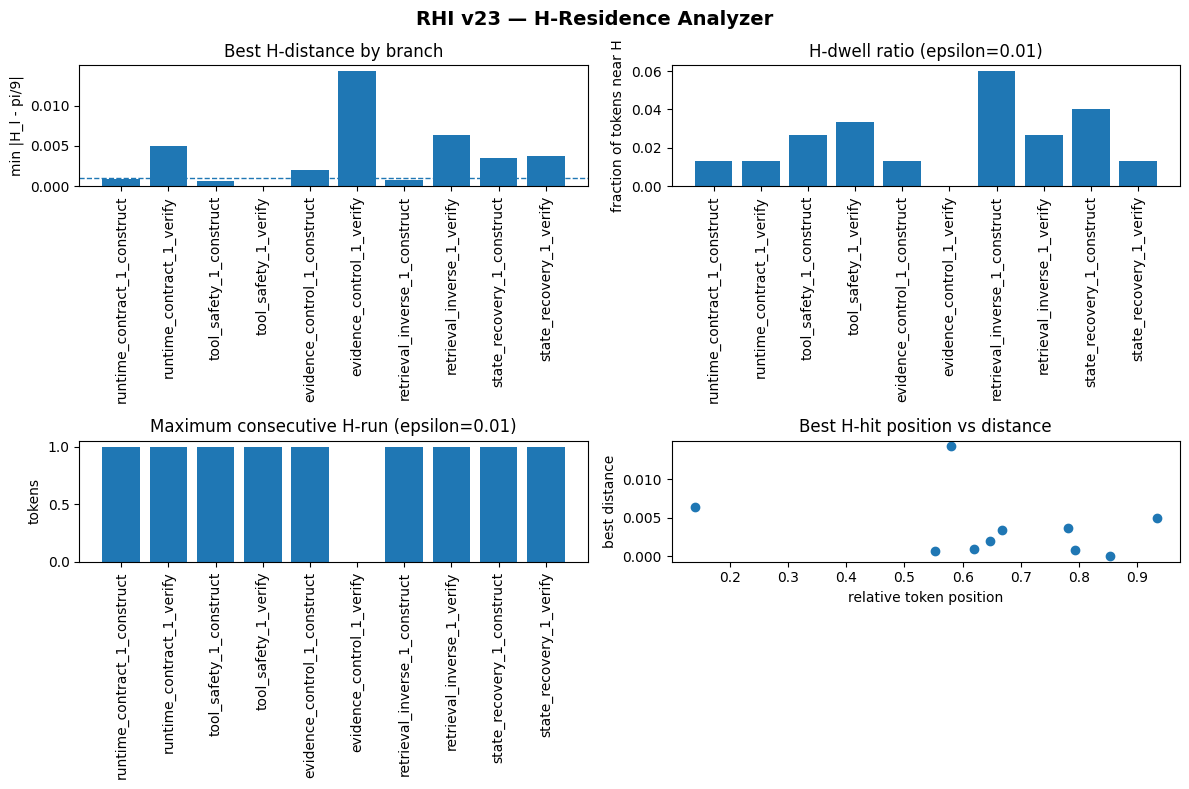

In [7]:

# Inline visualization only. Does not write a file.
if len(summary_df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("RHI v23 — H-Residence Analyzer", fontsize=14, fontweight="bold")

    axes[0,0].bar(summary_df["branch_id"], summary_df["best_distance"])
    axes[0,0].axhline(0.001, linestyle="--", linewidth=1)
    axes[0,0].set_title("Best H-distance by branch")
    axes[0,0].set_ylabel("min |H_l - pi/9|")
    axes[0,0].tick_params(axis="x", rotation=90)

    axes[0,1].bar(summary_df["branch_id"], summary_df["dwell_ratio_eps_0.01"])
    axes[0,1].set_title("H-dwell ratio (epsilon=0.01)")
    axes[0,1].set_ylabel("fraction of tokens near H")
    axes[0,1].tick_params(axis="x", rotation=90)

    axes[1,0].bar(summary_df["branch_id"], summary_df["max_run_eps_0.01"])
    axes[1,0].set_title("Maximum consecutive H-run (epsilon=0.01)")
    axes[1,0].set_ylabel("tokens")
    axes[1,0].tick_params(axis="x", rotation=90)

    axes[1,1].scatter(summary_df["best_relative_position"], summary_df["best_distance"])
    axes[1,1].set_title("Best H-hit position vs distance")
    axes[1,1].set_xlabel("relative token position")
    axes[1,1].set_ylabel("best distance")

    plt.tight_layout()
    plt.show()



## 7. Save Exactly Two Output Files

The output bundle contains all branch-level analysis and null summaries. The CSV is the compact per-branch summary.


In [8]:

output_bundle = {
    "run_id": RUN_ID,
    "version": "v23",
    "purpose": "h_residence_analyzer",
    "source_v22": {
        "run_id": v22.get("run_id"),
        "version": v22.get("version"),
        "purpose": v22.get("purpose"),
        "model": v22.get("model"),
        "bundle_path": str(bundle_path),
    },
    "h_target": H_TARGET,
    "epsilons": EPSILONS,
    "n_null": N_NULL,
    "aggregate": aggregate,
    "summary": summary_df.to_dict(orient="records"),
    "branch_results": branch_results,
    "interpretation_lock": {
        "crossing": "min-distance near H",
        "residence": "dwell ratio and consecutive run structure near H",
        "return": "out-of-H to in-H transitions",
        "rule": "H is a readout/destination, not a steering target",
    }
}

bundle_out = OUT_DIR / f"{RUN_ID}_bundle.json"
summary_out = OUT_DIR / f"{RUN_ID}_summary.csv"

with open(bundle_out, "w", encoding="utf-8") as f:
    json.dump(output_bundle, f, indent=2, ensure_ascii=False)

summary_df.to_csv(summary_out, index=False)

print("Saved exactly two output files:")
print(bundle_out)
print(summary_out)


Saved exactly two output files:
D:\Nexus\Nexus Mark 9\NoteBooks\rhi_v23_outputs\rhi_v23_1f5a545dca_bundle.json
D:\Nexus\Nexus Mark 9\NoteBooks\rhi_v23_outputs\rhi_v23_1f5a545dca_summary.csv



## 8. Reading the Result

Interpretation hierarchy:

$$
\text{near best-hit} \Rightarrow \text{crossing}
$$

$$
\text{large dwell ratio} \Rightarrow \text{residence candidate}
$$

$$
\text{long max run} \Rightarrow \text{local attractor candidate}
$$

$$
\text{strong z-score vs null} \Rightarrow \text{nontrivial structure candidate}
$$

The strongest result would be:

$$
\boxed{
\text{real max-run and dwell exceed matched null controls across branches.}
}
$$

The weakest result would be:

$$
\boxed{
\text{best-hit crossings occur, but residence/run structure is null-like.}
}
$$
